In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')


# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


### Loading Data

In [51]:

transaction_train = pd.read_csv('data/raw/train_transaction.csv')  #transaction training data
print(f"transaction_train.csv: {transaction_train.shape}")

identity_train = pd.read_csv('data/raw/train_identity.csv')   #identity training
print(f" identity_train.csv: {identity_train.shape}")

transaction_test = pd.read_csv('data/raw/train_transaction.csv')  #transaction testing data
print(f"transaction_test.csv: {transaction_test.shape}")

identity_test = pd.read_csv('data/raw/train_identity.csv')   #identity testing data
print(f" identity_test.csv: {identity_test.shape}")

transaction_train.csv: (590540, 394)
 identity_train.csv: (144233, 41)
transaction_test.csv: (590540, 394)
 identity_test.csv: (144233, 41)


### Overview

In [3]:
#Checking basic descriptive stats for transaction training data
transaction_train.head(5)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
identity_train.head(5)

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [5]:
transaction_cols_with_nulls = transaction_train.columns[transaction_train.isna().any()]
print(f"{len(transaction_cols_with_nulls)} out of {len(transaction_train)} columns have nulls values in transaction data.")

identity_cols_with_nulls = identity_train.columns[identity_train.isna().any()]
print(f"{len(identity_cols_with_nulls)} out of {len(identity_train)} columns have nulls values in identity data.")

374 out of 590540 columns have nulls values in transaction data.
38 out of 144233 columns have nulls values in identity data.


In [6]:
# Merging on TransactionID
train = transaction_train.merge(identity_train, on='TransactionID', how='left')
print(f" Merged dataset: {train.shape}")

 Merged dataset: (590540, 434)


In [7]:
#Target variable
print(f"Fraud cases: {train['isFraud'].sum():,}")
print(f"Legitimate cases: {(train['isFraud']==False).sum():,}")
print(f"Fraud rate: {train['isFraud'].mean()*100:.2f}%")

Fraud cases: 20,663
Legitimate cases: 569,877
Fraud rate: 3.50%


In [8]:
#Transaction time range
print(f"Min Transaction Date: {train['TransactionDT'].min():,}")
print(f"Max Transaction Date: {train['TransactionDT'].max():,}")
print(f"Range (days): {(train['TransactionDT'].max() - train['TransactionDT'].min()) / (24*3600):.1f}")

Min Transaction Date: 86,400
Max Transaction Date: 15,811,131
Range (days): 182.0


In [9]:
#Transaction Amounts
print(f"Min: ${train['TransactionAmt'].min():.2f}")
print(f"Max: ${train['TransactionAmt'].max():.2f}")
print(f"Mean: ${train['TransactionAmt'].mean():.2f}")
print(f"Median: ${train['TransactionAmt'].median():.2f}")

Min: $0.25
Max: $31937.39
Mean: $135.03
Median: $68.77


### Column Types Breakdown

In [10]:
# Identifying column types
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = train.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical columns: {len(categorical_cols)}")
print(f"Numerical columns: {len(numerical_cols)}")

Categorical columns: 31
Numerical columns: 403


### Missing Values Analysis

In [11]:
# Calculating missing value percentages
missing = pd.DataFrame({
    'column': train.columns,
    'missing_count': train.isnull().sum(),
    'missing_pct': train.isnull().sum() / len(train) * 100
}).sort_values('missing_pct', ascending=False)

# Summary stats
print(f"Columns with NO missing values: {(missing['missing_pct'] == 0).sum()}")
print(f"Columns with <10% missing: {((missing['missing_pct'] > 0) & (missing['missing_pct'] < 10)).sum()}")
print(f"Columns with 10-50% missing: {((missing['missing_pct'] >= 10) & (missing['missing_pct'] < 50)).sum()}")
print(f"Columns with 50-90% missing: {((missing['missing_pct'] >= 50) & (missing['missing_pct'] < 90)).sum()}")
print(f"Columns with >90% missing: {(missing['missing_pct'] >= 90).sum()}")

print("\n Top 30 columns with missing values:")
print(missing[missing['missing_pct'] > 0].head(30).to_string(index=False))

# Columns that should potentially be dropped (>90% missing)
high_missing = missing[missing['missing_pct'] > 90].column.tolist()
print(f"\n  Recommended dropping the following {len(high_missing)} columns with >90% missing values:")
print(high_missing)

Columns with NO missing values: 20
Columns with <10% missing: 92
Columns with 10-50% missing: 108
Columns with 50-90% missing: 202
Columns with >90% missing: 12

 Top 30 columns with missing values:
column  missing_count  missing_pct
 id_24         585793    99.196159
 id_25         585408    99.130965
 id_07         585385    99.127070
 id_08         585385    99.127070
 id_21         585381    99.126393
 id_26         585377    99.125715
 id_27         585371    99.124699
 id_23         585371    99.124699
 id_22         585371    99.124699
 dist2         552913    93.628374
    D7         551623    93.409930
 id_18         545427    92.360721
   D13         528588    89.509263
   D14         528353    89.469469
   D12         525823    89.041047
 id_03         524216    88.768923
 id_04         524216    88.768923
    D6         517353    87.606767
 id_33         517251    87.589494
 id_10         515614    87.312290
 id_09         515614    87.312290
    D9         515614    87.312

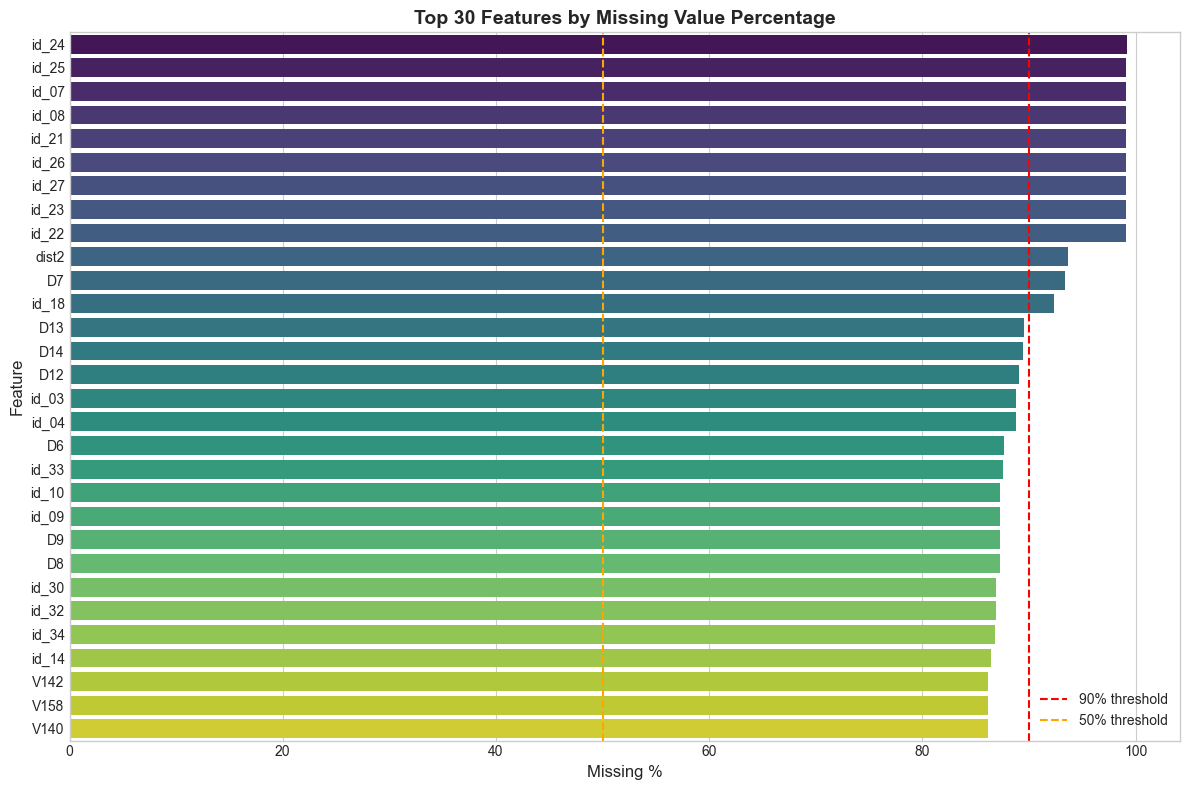

In [12]:
# Plotting top 30 features with missing values
top_missing_cols = missing[missing['missing_pct'] > 0].head(30)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_missing_cols, y='column', x='missing_pct', palette='viridis')
plt.title('Top 30 Features by Missing Value Percentage', fontsize=14, fontweight='bold')
plt.xlabel('Missing %', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(x=90, color='red', linestyle='--', label='90% threshold')
plt.axvline(x=50, color='orange', linestyle='--', label='50% threshold')
plt.legend()
plt.tight_layout()
plt.show()

### Target variable Analysis

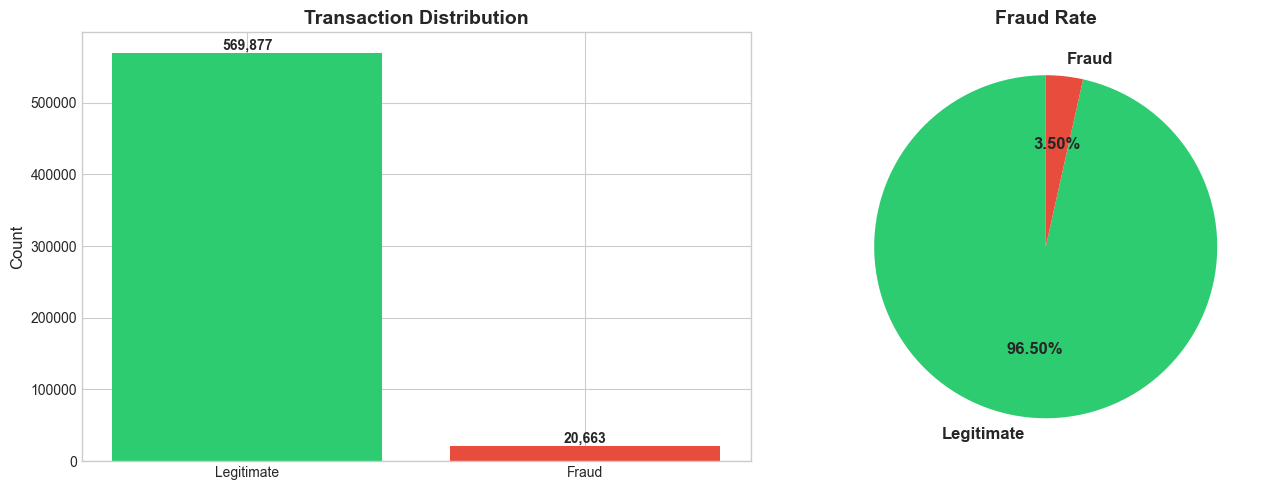

Class Imbalance Ratio: 1:27
This means for every 1 fraud, there are ~27 legitimate transactions


In [13]:
# Plots to depict Fraud Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar Chart
fraud_counts = train['isFraud'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], fraud_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Transaction Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraud'], 
            autopct='%1.2f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Fraud Rate', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Class Imbalance Ratio: 1:{int(fraud_counts[0]/fraud_counts[1])}")
print(f"This means for every 1 fraud, there are ~{int(fraud_counts[0]/fraud_counts[1])} legitimate transactions")

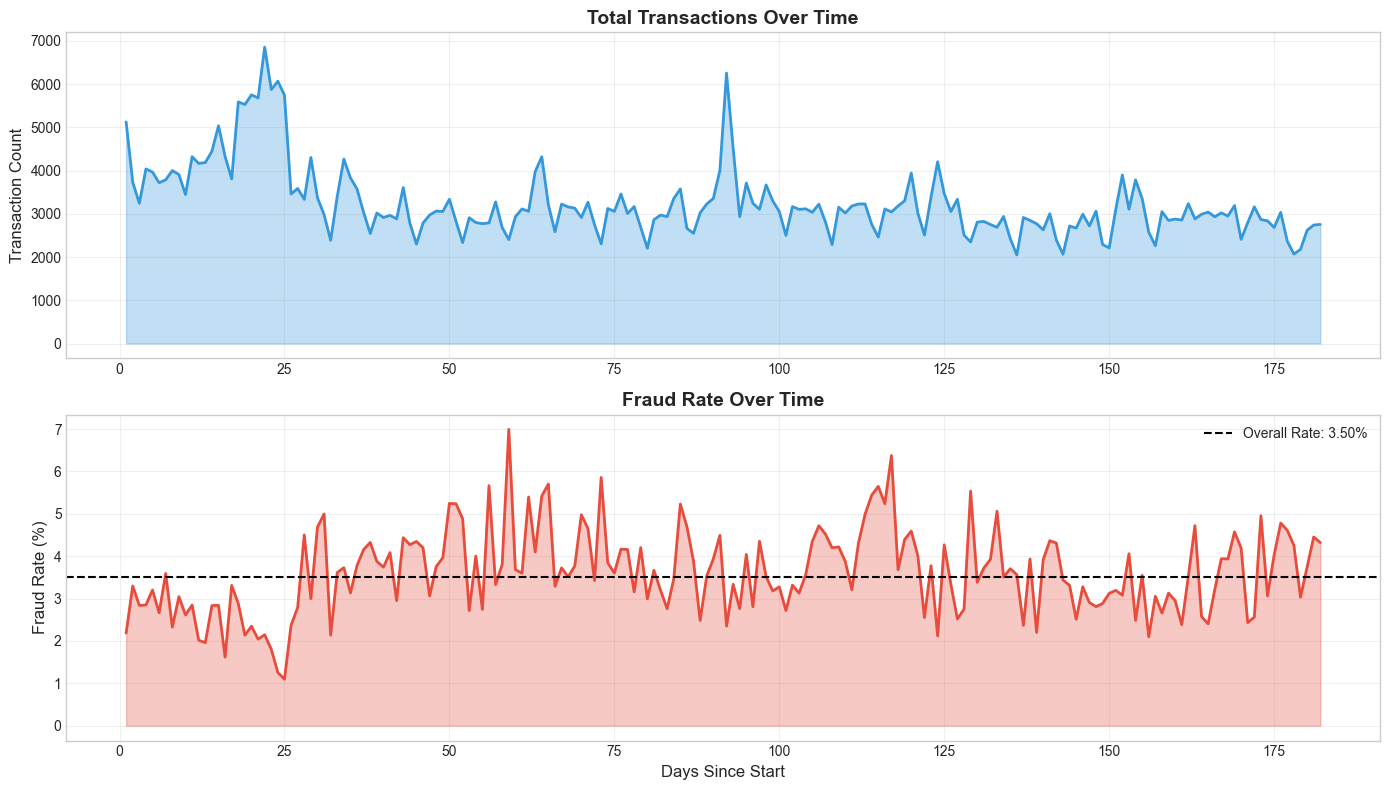

 Fraud Rate Statistics:
 Mean: 3.60%
 Std Dev: 1.00%
 Min: 1.10%
 Max: 6.99%

 Fraud rate is relatively stable over time


In [35]:
#Plots to depict fraud distribution over time

# Converting TransactionDT column to days for easier interpretation
train['TransactionDay'] = (train['TransactionDT'] / (3600 * 24)).astype(int)

# Calculating fraud rate by day
fraud_by_day = train.groupby('TransactionDay').agg({
    'isFraud': ['sum', 'count', 'mean']
}).reset_index()
fraud_by_day.columns = ['Day', 'Fraud_Count', 'Total_Transactions', 'Fraud_Rate']

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Total transactions over time
axes[0].plot(fraud_by_day['Day'], fraud_by_day['Total_Transactions'], 
             color='#3498db', linewidth=2)
axes[0].fill_between(fraud_by_day['Day'], fraud_by_day['Total_Transactions'], 
                      alpha=0.3, color='#3498db')
axes[0].set_title('Total Transactions Over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Transaction Count', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Fraud rate over time
axes[1].plot(fraud_by_day['Day'], fraud_by_day['Fraud_Rate'] * 100, 
             color='#e74c3c', linewidth=2)
axes[1].fill_between(fraud_by_day['Day'], fraud_by_day['Fraud_Rate'] * 100, 
                      alpha=0.3, color='#e74c3c')
axes[1].axhline(y=train['isFraud'].mean()*100, color='black', 
                linestyle='--', label=f'Overall Rate: {train["isFraud"].mean()*100:.2f}%')
axes[1].set_title('Fraud Rate Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Days Since Start', fontsize=12)
axes[1].set_ylabel('Fraud Rate (%)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical check: Is fraud rate stable?
print(f" Fraud Rate Statistics:")
print(f" Mean: {fraud_by_day['Fraud_Rate'].mean()*100:.2f}%")
print(f" Std Dev: {fraud_by_day['Fraud_Rate'].std()*100:.2f}%")
print(f" Min: {fraud_by_day['Fraud_Rate'].min()*100:.2f}%")
print(f" Max: {fraud_by_day['Fraud_Rate'].max()*100:.2f}%")

if fraud_by_day['Fraud_Rate'].std() < 0.01:
    print("\n Fraud rate is relatively stable over time")
else:
    print("\n  Fraud rate shows variation over time")

### Transaction Amount Analysis

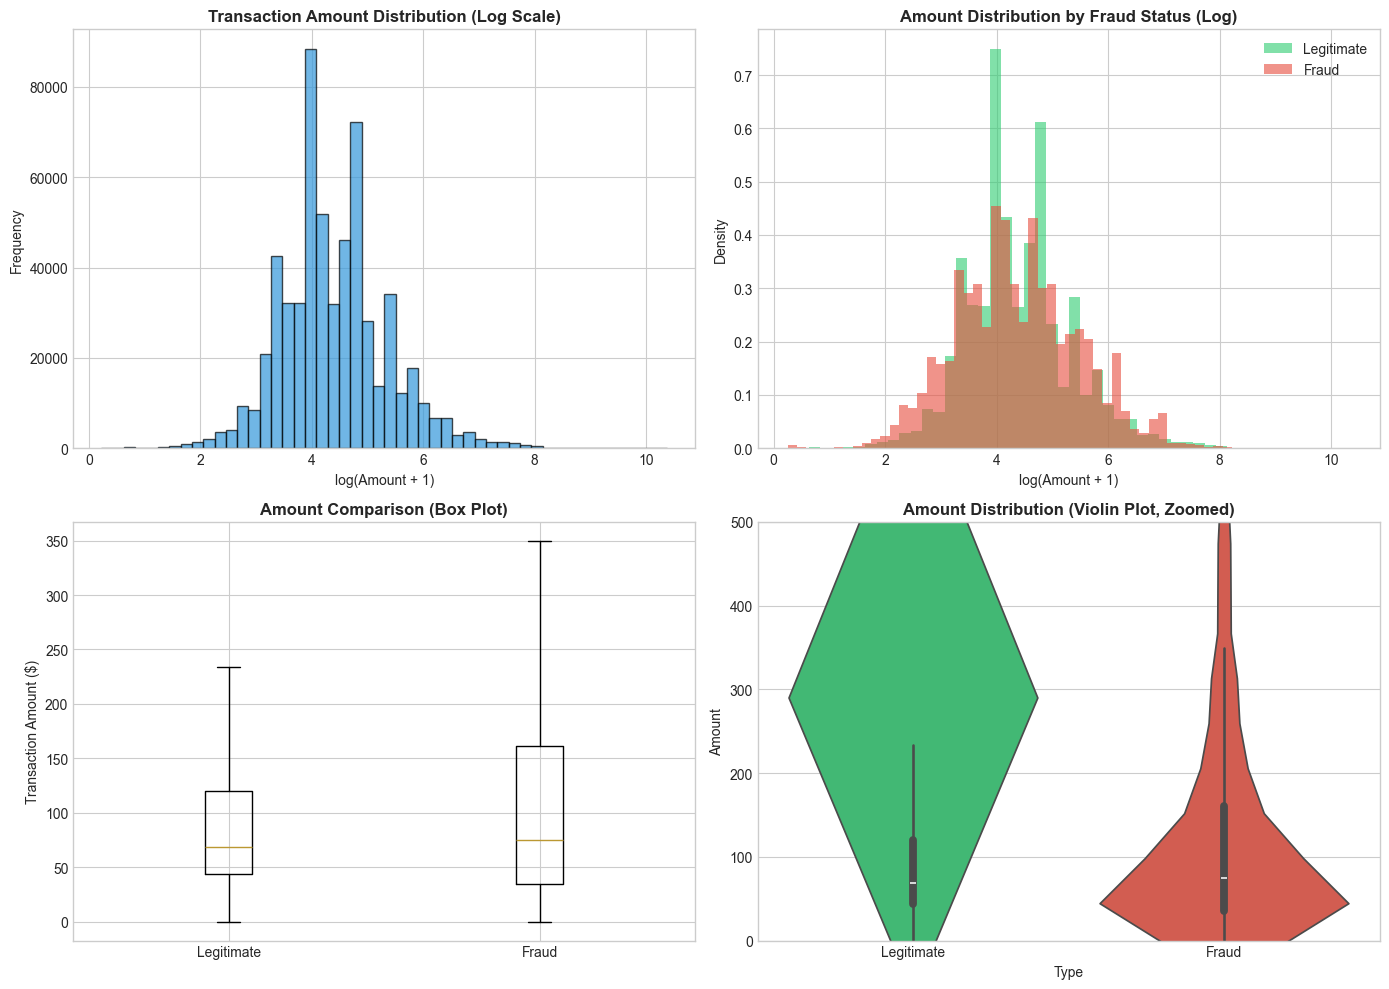

Transaction Amount Statistics:

Metric                    Legitimate           Fraud
Mean                 $        134.51 $        149.24
Median               $         68.50 $         75.00
Std Dev              $        239.40 $        232.21
Min                  $          0.25 $          0.29
Max                  $      31937.39 $       5191.00


In [36]:
#Plots analysing Transaction Amount

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Overall distribution (log scale)
axes[0, 0].hist(np.log1p(train['TransactionAmt']), bins=50, 
                color='#3498db', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Transaction Amount Distribution (Log Scale)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('log(Amount + 1)')
axes[0, 0].set_ylabel('Frequency')

# By fraud status (log scale)
axes[0, 1].hist(np.log1p(train[train['isFraud']==0]['TransactionAmt']), 
                bins=50, alpha=0.6, label='Legitimate', color='#2ecc71', density=True)
axes[0, 1].hist(np.log1p(train[train['isFraud']==1]['TransactionAmt']), 
                bins=50, alpha=0.6, label='Fraud', color='#e74c3c', density=True)
axes[0, 1].set_title('Amount Distribution by Fraud Status (Log)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('log(Amount + 1)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()

# Box plot comparison
fraud_amounts = train[train['isFraud']==1]['TransactionAmt']
legit_amounts = train[train['isFraud']==0]['TransactionAmt']
axes[1, 0].boxplot([legit_amounts, fraud_amounts], labels=['Legitimate', 'Fraud'],
                    showfliers=False)  # Hide outliers for clarity
axes[1, 0].set_title('Amount Comparison (Box Plot)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Transaction Amount ($)')

# Violin plot
data_to_plot = pd.DataFrame({
    'Amount': train['TransactionAmt'],
    'Type': train['isFraud'].map({0: 'Legitimate', 1: 'Fraud'})
})
sns.violinplot(data=data_to_plot, x='Type', y='Amount', ax=axes[1, 1], 
               palette={'Legitimate': '#2ecc71', 'Fraud': '#e74c3c'})
axes[1, 1].set_ylim(0, 500)  # Focus on main range
axes[1, 1].set_title('Amount Distribution (Violin Plot, Zoomed)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Statistical comparison
print("Transaction Amount Statistics:\n")
print(f"{'Metric':<20} {'Legitimate':>15} {'Fraud':>15}")
print(f"{'Mean':<20} ${legit_amounts.mean():>14.2f} ${fraud_amounts.mean():>14.2f}")
print(f"{'Median':<20} ${legit_amounts.median():>14.2f} ${fraud_amounts.median():>14.2f}")
print(f"{'Std Dev':<20} ${legit_amounts.std():>14.2f} ${fraud_amounts.std():>14.2f}")
print(f"{'Min':<20} ${legit_amounts.min():>14.2f} ${fraud_amounts.min():>14.2f}")
print(f"{'Max':<20} ${legit_amounts.max():>14.2f} ${fraud_amounts.max():>14.2f}")

### Analysis Of Categorical features

In [17]:
print(f"List of categorical columns:")
for col in categorical_cols:
    unique_count = train[col].nunique()
    print(f"   • {col:<20} ({unique_count:>5} unique values)")


List of categorical columns:
   • ProductCD            (    5 unique values)
   • card4                (    4 unique values)
   • card6                (    4 unique values)
   • P_emaildomain        (   59 unique values)
   • R_emaildomain        (   60 unique values)
   • M1                   (    2 unique values)
   • M2                   (    2 unique values)
   • M3                   (    2 unique values)
   • M4                   (    3 unique values)
   • M5                   (    2 unique values)
   • M6                   (    2 unique values)
   • M7                   (    2 unique values)
   • M8                   (    2 unique values)
   • M9                   (    2 unique values)
   • id_12                (    2 unique values)
   • id_15                (    3 unique values)
   • id_16                (    2 unique values)
   • id_23                (    3 unique values)
   • id_27                (    2 unique values)
   • id_28                (    2 unique values)
   • id_29 

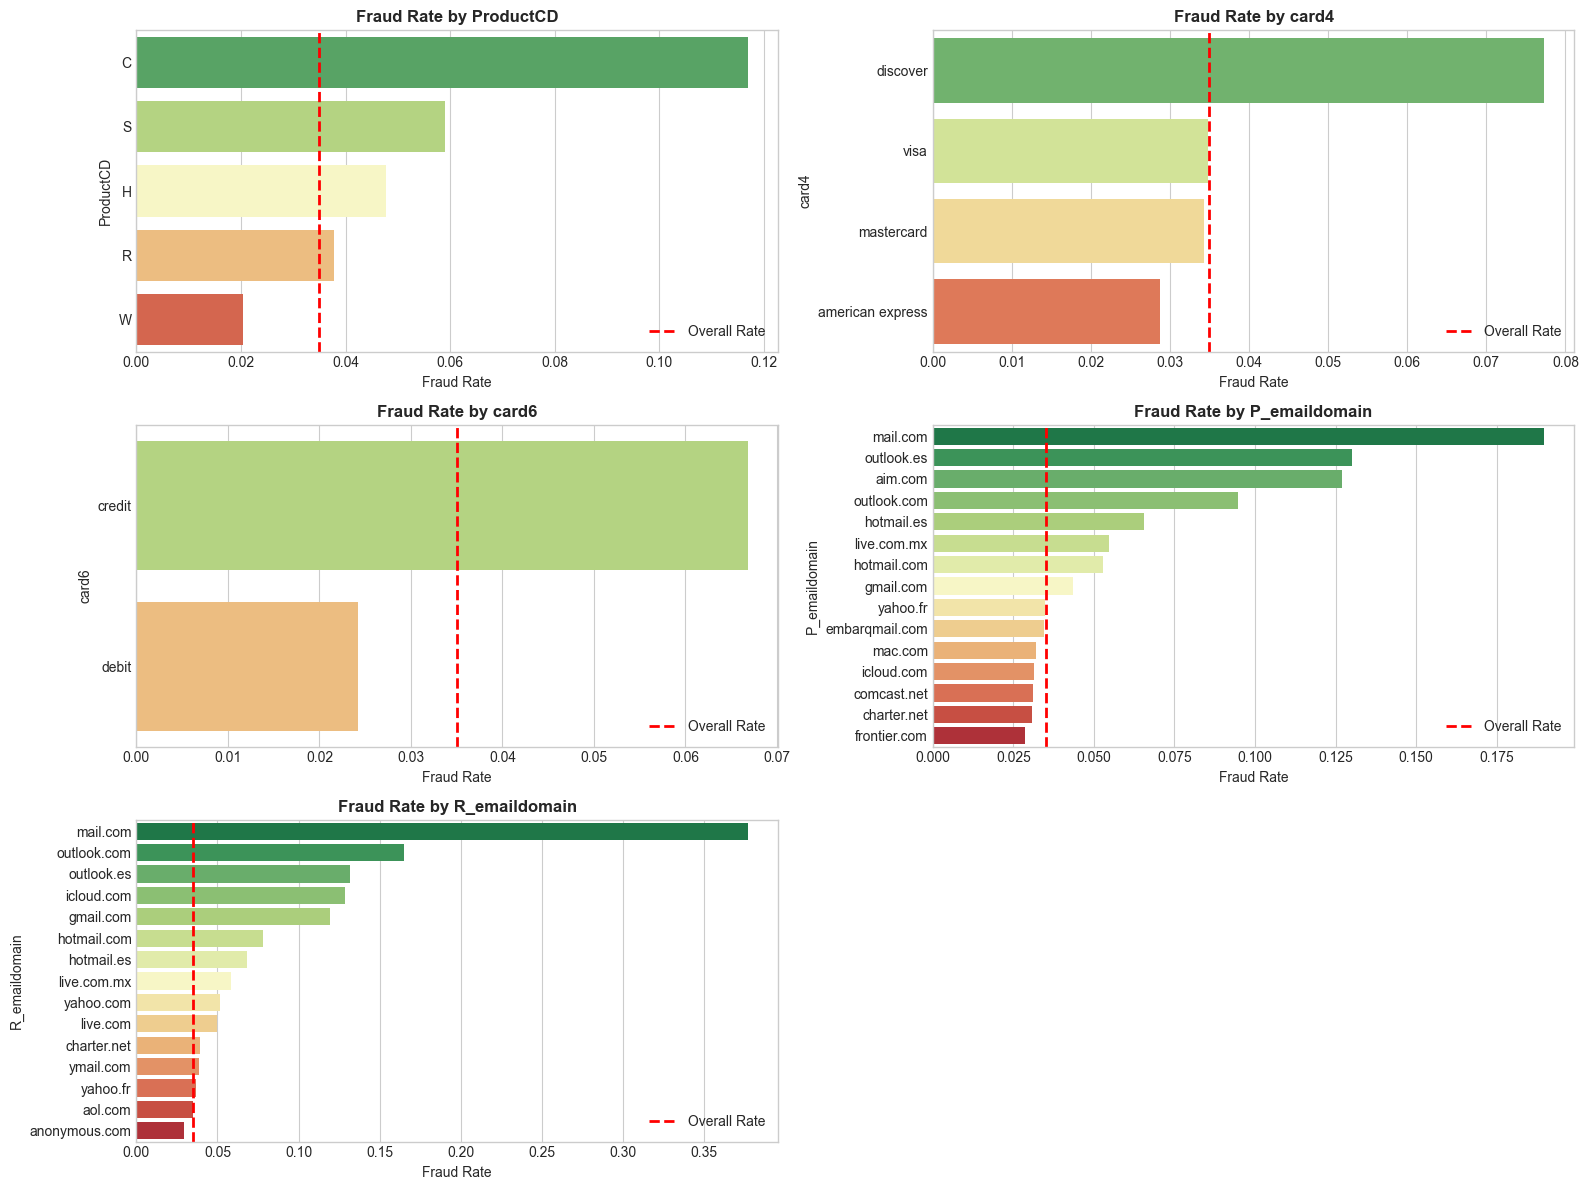

In [18]:
# Analyzing key categorical features
categorical_features = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(categorical_features):
    if col in train.columns:
        # Calculate fraud rate by category
        fraud_rate = train.groupby(col)['isFraud'].agg(['mean', 'count']).reset_index()
        fraud_rate = fraud_rate[fraud_rate['count'] > 100]  # Filter rare categories
        fraud_rate = fraud_rate.sort_values('mean', ascending=False).head(15)
        
        # Plot
        sns.barplot(data=fraud_rate, y=col, x='mean', ax=axes[idx], 
                    palette='RdYlGn_r')
        axes[idx].set_title(f'Fraud Rate by {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Fraud Rate')
        axes[idx].axvline(x=train['isFraud'].mean(), color='red', 
                         linestyle='--', linewidth=2, label='Overall Rate')
        axes[idx].legend()

# Removing empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### Analysing ProductCD feature

           Total_Transactions  Fraud_Count  Fraud_Rate  Avg_Amount  \
ProductCD                                                            
C                       68519         8008      0.1169     42.8724   
S                       11628          686      0.0590     60.2695   
H                       33024         1574      0.0477     73.1701   
R                       37699         1426      0.0378    168.3062   
W                      439670         8969      0.0204    153.1586   

           Median_Amount  
ProductCD                 
C                 31.191  
S                 35.000  
H                 50.000  
R                125.000  
W                 78.500  


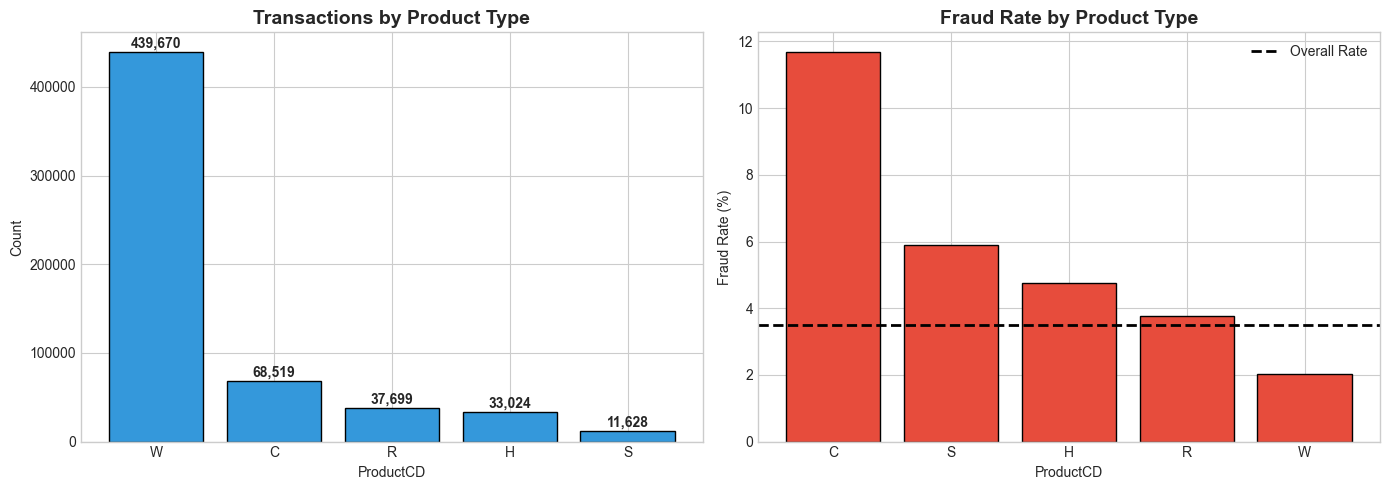

In [37]:
# Finding Distribution of values
product_stats = train.groupby('ProductCD').agg({
    'TransactionID': 'count',
    'isFraud': ['sum', 'mean'],
    'TransactionAmt': ['mean', 'median']
}).round(4)

product_stats.columns = ['Total_Transactions', 'Fraud_Count', 'Fraud_Rate', 'Avg_Amount', 'Median_Amount']
product_stats = product_stats.sort_values('Fraud_Rate', ascending=False)

print(product_stats)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transaction count by product
product_counts = train['ProductCD'].value_counts()
axes[0].bar(product_counts.index, product_counts.values, color='#3498db', edgecolor='black')
axes[0].set_title('Transactions by Product Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('ProductCD')
axes[0].set_ylabel('Count')
for i, v in enumerate(product_counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')

# Fraud rate by product
axes[1].bar(product_stats.index, product_stats['Fraud_Rate'] * 100, 
            color='#e74c3c', edgecolor='black')
axes[1].axhline(y=train['isFraud'].mean()*100, color='black', 
                linestyle='--', linewidth=2, label='Overall Rate')
axes[1].set_title('Fraud Rate by Product Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('ProductCD')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

### Feature Correlations with Fraud

Top 35 features correlated with fraud:

V257    0.365644
V246    0.346830
V244    0.344396
V242    0.341745
V201    0.312907
V200    0.300456
V258    0.296730
V189    0.295821
V158    0.294606
V156    0.289826
V188    0.284976
V149    0.284951
V45     0.274864
V147    0.260213
V228    0.252162
V44     0.249859
V52     0.245046
V87     0.244962
V86     0.244412
V170    0.244389
V157    0.237440
V155    0.237411
V199    0.233394
V148    0.230305
V230    0.230065
V51     0.229861
V40     0.212908
V140    0.212808
V171    0.212340
V154    0.211655
V243    0.209335
V43     0.205590
V190    0.205196
V146    0.204838
V39     0.204722


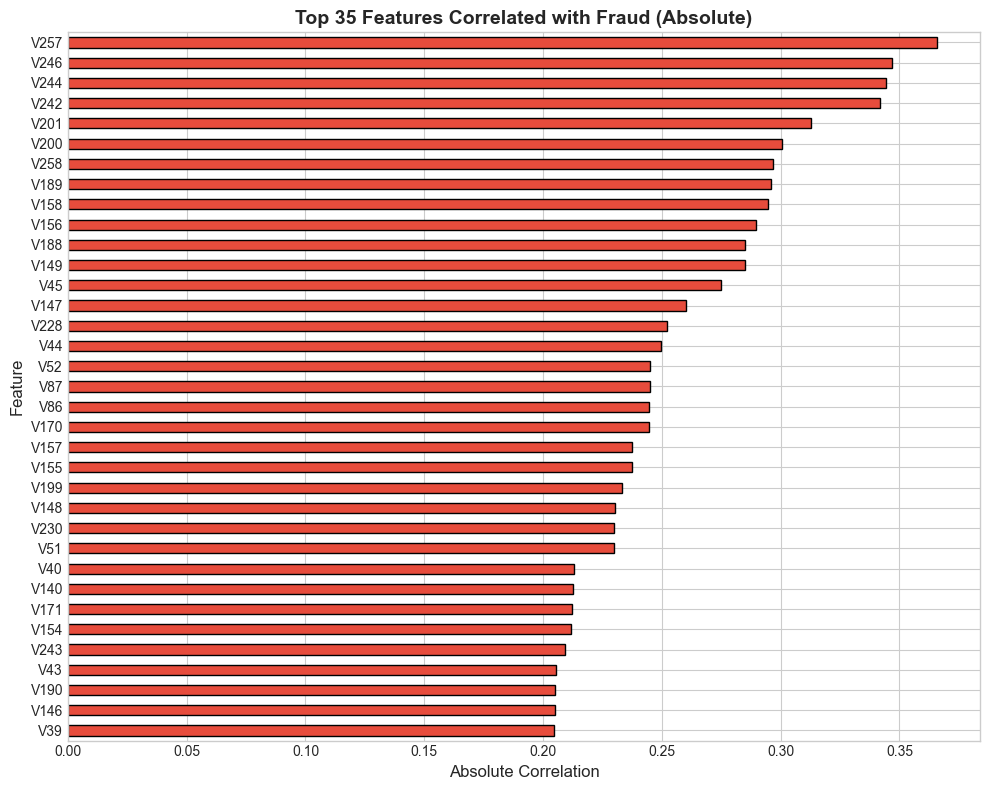

In [59]:
# Selecting numerical features only
numerical_features = train.select_dtypes(include=[np.number]).columns.tolist()
numerical_features.remove('isFraud')
numerical_features.remove('TransactionID')

# Calculating correlations (use a sample if too slow)
sample_size = min(100000, len(train))
train_sample = train[numerical_features + ['isFraud']].sample(sample_size, random_state=42)

correlations = train_sample.corr()['isFraud'].drop('isFraud')
correlations = correlations.abs().sort_values(ascending=False).head(35)

print("Top 35 features correlated with fraud:\n")
print(correlations.to_string())

# Visualization
plt.figure(figsize=(10, 8))
correlations.sort_values().plot(kind='barh', color='#e74c3c', edgecolor='black')
plt.title('Top 35 Features Correlated with Fraud (Absolute)', fontsize=14, fontweight='bold')
plt.xlabel('Absolute Correlation', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

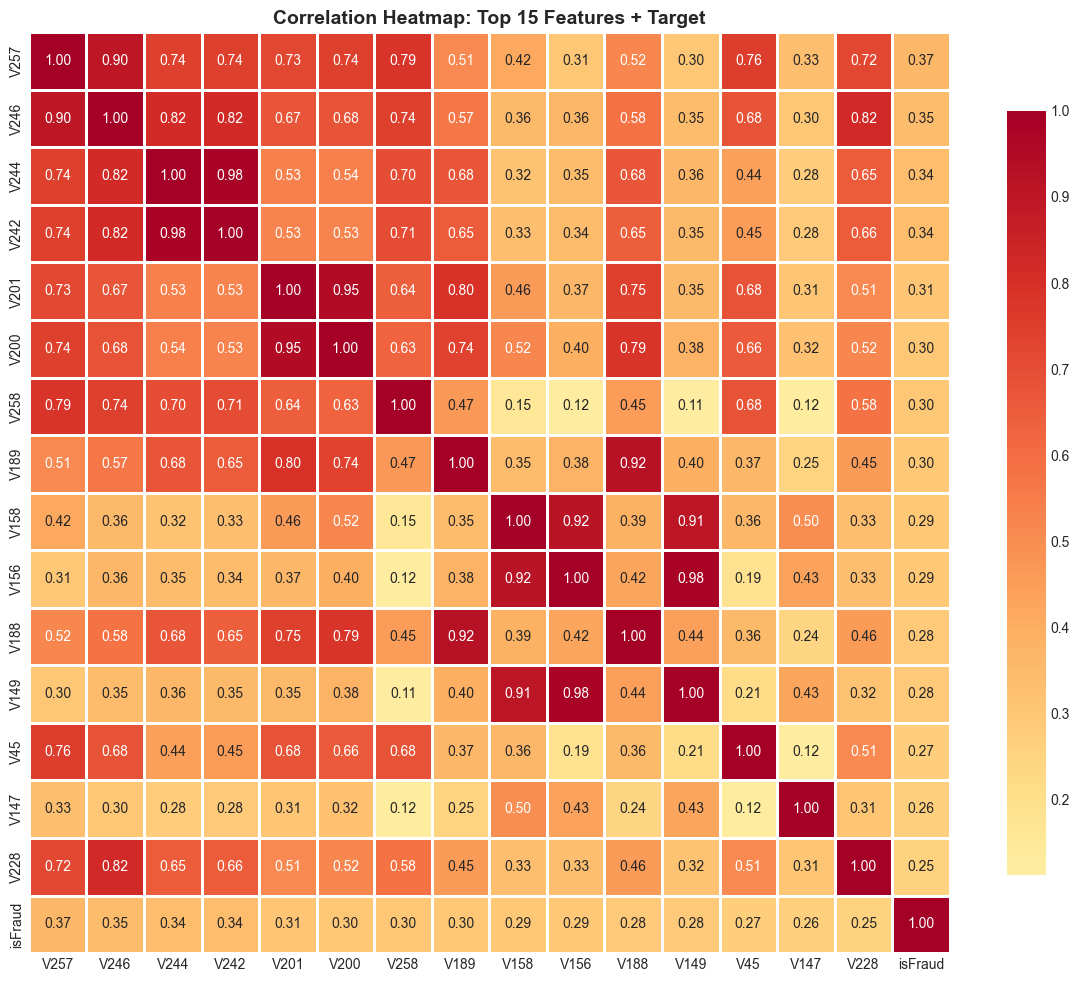

In [42]:
# Selecting top correlated features for heatmap
top_features = correlations.head(15).index.tolist()
top_features.append('isFraud')

# Calculating correlation matrix
corr_matrix = train_sample[top_features].corr()

# Plotting heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Top 15 Features + Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Analysing Card Features

In [43]:
card_features = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6']

for col in card_features:
    if col in train.columns:
        n_unique = train[col].nunique()
        missing_pct = train[col].isnull().sum() / len(train) * 100
        
        # Fraud rate correlation
        if train[col].dtype in [np.int64, np.float64]:
            corr = train[[col, 'isFraud']].corr().iloc[0, 1]
            print(f"{col:<10} | Unique: {n_unique:>6,} | Missing: {missing_pct:>5.1f}% | Correlation: {corr:>6.4f}")
        else:
            print(f"{col:<10} | Unique: {n_unique:>6,} | Missing: {missing_pct:>5.1f}% | Type: Categorical")


card1      | Unique: 13,553 | Missing:   0.0% | Correlation: -0.0136
card2      | Unique:    500 | Missing:   1.5% | Correlation: 0.0034
card3      | Unique:    114 | Missing:   0.3% | Correlation: 0.1542
card4      | Unique:      4 | Missing:   0.3% | Type: Categorical
card5      | Unique:    119 | Missing:   0.7% | Correlation: -0.0336
card6      | Unique:      4 | Missing:   0.3% | Type: Categorical


### Analysing Email Domains

In [44]:
# Purchaser email
if 'P_emaildomain' in train.columns:
    print("PURCHASER EMAIL DOMAINS (P_emaildomain):")
    print(f"  Total unique domains: {train['P_emaildomain'].nunique()}")
    print(f"  Missing: {train['P_emaildomain'].isnull().sum():,} ({train['P_emaildomain'].isnull().mean()*100:.1f}%)")
    
    # Top domains
    top_p_domains = train.groupby('P_emaildomain').agg({
        'TransactionID': 'count',
        'isFraud': 'mean'
    }).sort_values('TransactionID', ascending=False).head(10)
    top_p_domains.columns = ['Count', 'Fraud_Rate']
    print("\n  Top 10 domains:")
    print(top_p_domains.to_string())

# Recipient email
if 'R_emaildomain' in train.columns:
    print("RECIPIENT EMAIL DOMAINS (R_emaildomain):")
    print(f"  Total unique domains: {train['R_emaildomain'].nunique()}")
    print(f"  Missing: {train['R_emaildomain'].isnull().sum():,} ({train['R_emaildomain'].isnull().mean()*100:.1f}%)")
    
    # Top domains
    top_r_domains = train.groupby('R_emaildomain').agg({
        'TransactionID': 'count',
        'isFraud': 'mean'
    }).sort_values('TransactionID', ascending=False).head(10)
    top_r_domains.columns = ['Count', 'Fraud_Rate']
    print("\n  Top 10 domains:")
    print(top_r_domains.to_string())

PURCHASER EMAIL DOMAINS (P_emaildomain):
  Total unique domains: 59
  Missing: 94,456 (16.0%)

  Top 10 domains:
                Count  Fraud_Rate
P_emaildomain                    
gmail.com      228355    0.043542
yahoo.com      100934    0.022757
hotmail.com     45250    0.052950
anonymous.com   36998    0.023217
aol.com         28289    0.021811
comcast.net      7888    0.031187
icloud.com       6267    0.031434
outlook.com      5096    0.094584
msn.com          4092    0.021994
att.net          4033    0.007439
RECIPIENT EMAIL DOMAINS (R_emaildomain):
  Total unique domains: 60
  Missing: 453,249 (76.8%)

  Top 10 domains:
               Count  Fraud_Rate
R_emaildomain                   
gmail.com      57147    0.119184
hotmail.com    27509    0.077793
anonymous.com  20529    0.029130
yahoo.com      11842    0.051512
aol.com         3701    0.034855
outlook.com     2507    0.165138
comcast.net     1812    0.011589
yahoo.com.mx    1508    0.010610
icloud.com      1398    0.128755
ms

### Summarizing Findings

In [48]:
print("\n DATA QUALITY")
print(f"   • Total transactions: {len(train):,}")
print(f"   • Total features: {len(train.columns)}")
print(f"   • Fraud rate: {train['isFraud'].mean()*100:.2f}% (highly imbalanced)")
print(f"   • Features with >90% missing: {len(missing[missing['missing_pct'] > 90])}")
print(f"   • Recommendation: Drop high-missing features, impute others")

print("\n TEMPORAL PATTERNS")
fraud_rate_std = fraud_by_day['Fraud_Rate'].std()
if fraud_rate_std < 0.01:
    print(f"   • Fraud rate over time: Stable ( less than std={fraud_rate_std:.4f})")
    print(f"   • Time-based split is Valid")
else:
    print(f"   • Fraud rate over time: Variable (std={fraud_rate_std:.4f})")
    print(f"   • Consider seasonal effects in modeling")

print("\n TRANSACTION AMOUNTS")
mean_diff = fraud_amounts.mean() - legit_amounts.mean()
if mean_diff > 0:
    print(f"   • Fraud transactions are ${mean_diff:.2f} Higher on average")
else:
    print(f"   • Fraud transactions are ${abs(mean_diff):.2f} Lower on average")
print(f"   • High variance in both classes")
print(f"   • Strategy: Consider log transformation or amount-based features")

print("\n  IMPORTANT FEATURE GROUPS")
print(f"   • Top correlated feature: {correlations.index[0]} (r={correlations.iloc[0]:.4f})")
print(f"   • Card features: 6 available, varying cardinality")
print(f"   • Email domains: Predictive power (fraud rate varies by domain)")
print(f"   • V-columns: {len([c for c in train.columns if c.startswith('V')])} anonymized features")

print("\n  CLASS IMBALANCE STRATEGY")
print(f"   • Imbalance ratio: 1:{int((train['isFraud']==0).sum() / (train['isFraud']==1).sum())}")
print(f"   • Will use: class_weight='balanced' in models")
print(f"   • Will use: Precision-Recall metrics (not accuracy)")
print(f"   • Will use: Threshold optimization for business cost")

print("\n  NEXT STEPS")
print(f"   1. Drop {len(missing[missing['missing_pct'] > 90])} features with >90% missing")
print(f"   2. Engineer time-based features (hour, day, time since last transaction)")
print(f"   3. Create aggregation features (velocity, user behavior patterns)")
print(f"   4. Encode categorical features (target encoding for high-cardinality)")
print(f"   5. Create time-based train/val/test splits (70/15/15)")


 DATA QUALITY
   • Total transactions: 590,540
   • Total features: 435
   • Fraud rate: 3.50% (highly imbalanced)
   • Features with >90% missing: 12
   • Recommendation: Drop high-missing features, impute others

 TEMPORAL PATTERNS
   • Fraud rate over time: Stable ( less than std=0.0100)
   • Time-based split is Valid

 TRANSACTION AMOUNTS
   • Fraud transactions are $14.73 Higher on average
   • High variance in both classes
   • Strategy: Consider log transformation or amount-based features

  IMPORTANT FEATURE GROUPS
   • Top correlated feature: V257 (r=0.3656)
   • Card features: 6 available, varying cardinality
   • Email domains: Predictive power (fraud rate varies by domain)
   • V-columns: 339 anonymized features

  CLASS IMBALANCE STRATEGY
   • Imbalance ratio: 1:27
   • Will use: class_weight='balanced' in models
   • Will use: Precision-Recall metrics (not accuracy)
   • Will use: Threshold optimization for business cost

  NEXT STEPS
   1. Drop 12 features with >90% mis